## Importing the relevant packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
import statsmodels.tsa.stattools as sts
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats.distributions import chi2 
from math import sqrt
import seaborn as sns
sns.set()

## Importing the Data and Pre-processing 

In [2]:
raw_csv_data = pd.read_csv("Index2018.csv") 
df_comp=raw_csv_data.copy()
df_comp.date = pd.to_datetime(df_comp.date, dayfirst = True)
df_comp.set_index("date", inplace=True)
df_comp=df_comp.asfreq('b')
df_comp=df_comp.ffill()

In [3]:
df_comp['market_value']=df_comp.ftse

In [4]:
del df_comp['spx']
del df_comp['dax']
del df_comp['ftse']
del df_comp['nikkei']
size = int(len(df_comp)*0.8)
df, df_test = df_comp.iloc[:size], df_comp.iloc[size:]

In [5]:
import warnings
warnings.filterwarnings("ignore")

## The LLR Test

In [6]:
def LLR_test(mod_1, mod_2, DF = 1):
    L1 = mod_1.fit().llf
    L2 = mod_2.fit().llf
    LR = (2*(L2-L1))    
    p = chi2.sf(LR, DF).round(3)
    return p

## Creating Returns

In [7]:
df['returns'] = df.market_value.pct_change(1)*100

## Creating Squared Returns

In [8]:
df['sqr_returns'] = df.returns.mul(df.returns)

## Returns vs Squared Returns

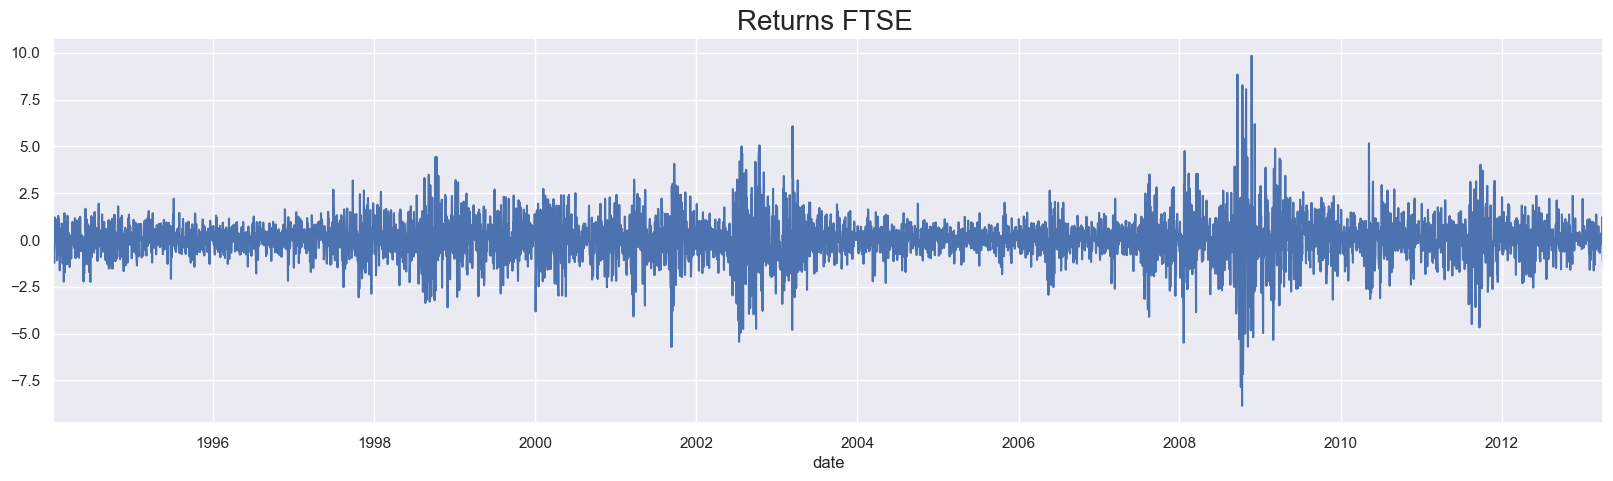

In [9]:
# Plotting Returns 
df.returns.plot(figsize=(20,5))
plt.title("Returns FTSE ",size=20)
plt.show()

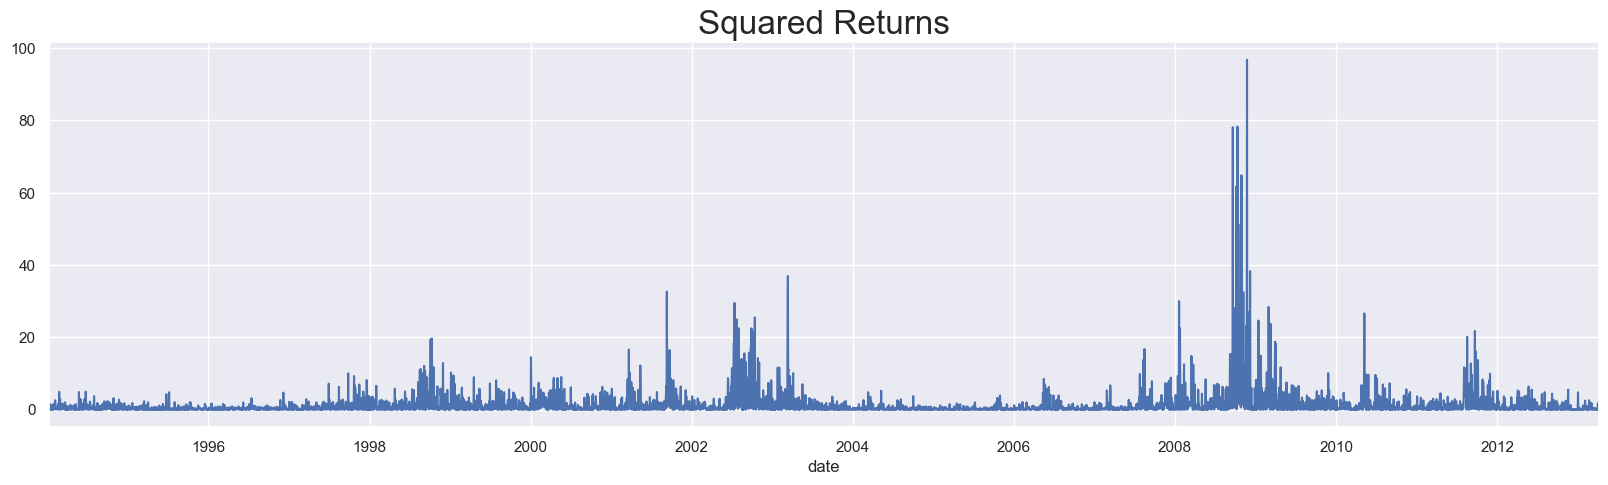

In [10]:
# Plotting Squared Returns
df.sqr_returns.plot(figsize=(20,5))
plt.title("Squared Returns",size=24)
plt.show()

`From the plot we can see that low volatility follows low volatility and high follows high`                                
`This is known as Volatility Clustering`

`We can check for how many lags model will be enough by looking at PACF Plot unlike ARIMA`

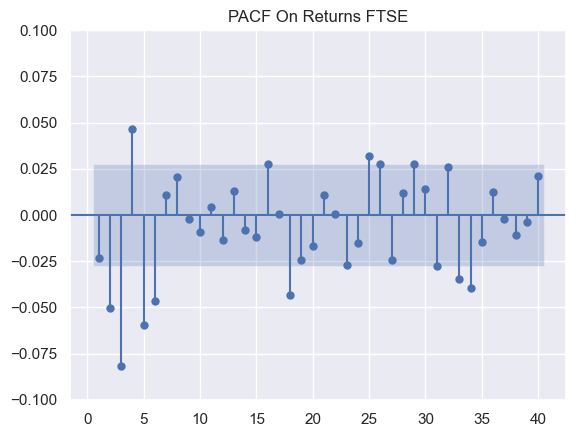

In [11]:
# Plotting PACF On Returns
sgt.plot_pacf(df.returns[1:],lags=40, zero=False, alpha=0.05, method=('ols'))
plt.title("PACF On Returns FTSE")
plt.ylim(-.1,.1)
plt.show()

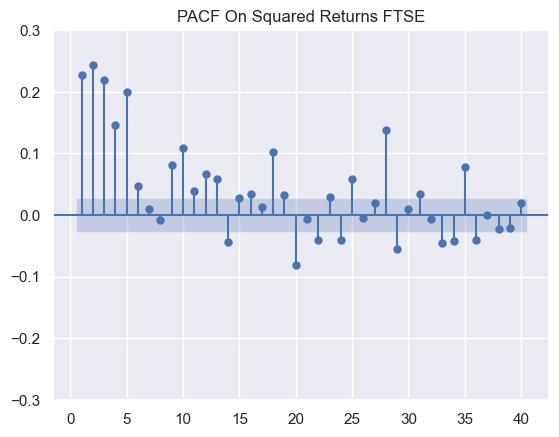

In [12]:
# Plotting PACF On Squared Returns
sgt.plot_pacf(df.sqr_returns[1:],lags=40, zero=False, alpha=0.05, method=('ols'))
plt.title("PACF On Squared Returns FTSE")
plt.ylim(-.3,.3)
plt.show()

`We see that First 6 lag models looks a good fit for the data`

In [13]:
# We can fit the mean of returns or prices using our ordinary ARIMA Models, but the volatility trend is captured by ARCH
# models only! 

`ARCH Model has two equations -> 1 for mean and 2nd for Variance`                                                           
## ARCH(q) Model

### Mean Equation
$$y_t = \mu + \varepsilon_t$$

### Volatility (Variance) Equation
$$\varepsilon_t = \sigma_t z_t, \quad z_t \overset{iid}{\sim} \mathcal{N}(0, 1)$$

$$\sigma_t^2 = \alpha_0 + \sum_{i=1}^{q} \alpha_i \, \varepsilon_{t-i}^2$$

### Parameter Constraints (for stationarity)
$$\alpha_0 > 0, \quad \alpha_i \geq 0 \; \forall i, \quad \sum_{i=1}^{q} \alpha_i < 1$$

### Conditional Distribution
$$y_t \mid \mathcal{F}_{t-1} \sim \mathcal{N}(\mu,\; \sigma_t^2)$$

## The arch_model() Method

In [15]:
from arch import arch_model

In [ ]:
model_arch_1 = arch_model(df.returns[1:]) # This is the default arch model on  returns data
result_arch_1 = model_arch_1.fit(update_freq=5)
print(result_arch_1.summary())

Iteration:      5,   Func. Count:     35,   Neg. LLF: 7010.712887007633
Iteration:     10,   Func. Count:     64,   Neg. LLF: 6970.058478413694
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6970.058366189882
            Iterations: 13
            Function evaluations: 78
            Gradient evaluations: 13
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6970.06
Distribution:                  Normal   AIC:                           13948.1
Method:            Maximum Likelihood   BIC:                           13974.2
                                        No. Observations:                 5020
Date:                Wed, Apr 29 2026   Df Residuals:                     5019
Time:          

## The Simple ARCH(1) 

In [25]:
# here p = 1 shows that volatility component is 1 and by default q = 1 i.e mean component

In [24]:
# Making Simple ARCH(1) Model
model_arch_1 = arch_model(df.returns[1:], mean='Constant', vol='ARCH',p=1)
result_arch_1 = model_arch_1.fit()
print(result_arch_1.summary())

Iteration:      1,   Func. Count:      5,   Neg. LLF: 29071.83486537579
Iteration:      2,   Func. Count:     13,   Neg. LLF: 12040.736044828116
Iteration:      3,   Func. Count:     20,   Neg. LLF: 7809.7227529035545
Iteration:      4,   Func. Count:     26,   Neg. LLF: 7660.088789376123
Iteration:      5,   Func. Count:     30,   Neg. LLF: 7660.088782040875
Iteration:      6,   Func. Count:     33,   Neg. LLF: 7660.088782040906
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7660.088782040875
            Iterations: 6
            Function evaluations: 33
            Gradient evaluations: 6
                      Constant Mean - ARCH Model Results                      
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -7660.09
Distribution:                  Normal   AIC

`Mean component is Significant as well as Variance component is Also significant`

`This model is a good start, We also see that it performs better than those complex ARIMAX model`

## Higher-Lag ARCH Models

In [23]:
model_arch_2 = model_arch_2 = arch_model(df.returns[1:], mean='Constant', vol='ARCH',p=2)
result_arch_2 = model_arch_2.fit()
print(result_arch_2.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 34336.61062838968
Iteration:      2,   Func. Count:     15,   Neg. LLF: 11809.810463437398
Iteration:      3,   Func. Count:     24,   Neg. LLF: 7900.582867042022
Iteration:      4,   Func. Count:     31,   Neg. LLF: 7647.101576187482
Iteration:      5,   Func. Count:     37,   Neg. LLF: 8810.02930517937
Iteration:      6,   Func. Count:     44,   Neg. LLF: 7449.551200532487
Iteration:      7,   Func. Count:     49,   Neg. LLF: 7449.545177539265
Iteration:      8,   Func. Count:     54,   Neg. LLF: 7449.545164098316
Iteration:      9,   Func. Count:     58,   Neg. LLF: 7449.545164098206
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7449.545164098316
            Iterations: 9
            Function evaluations: 58
            Gradient evaluations: 9
                      Constant Mean - ARCH Model Results                      
Dep. Variable:                returns   R-squared:                

`ARCH(2) > ARCH(1)`

In [26]:
# ARCH(3) Model
model_arch_3 = arch_model(df.returns[1:], mean='Constant', vol='ARCH',p=3,q=1)
result_arch_3 = model_arch_3.fit()
print(result_arch_3.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 39962.465851469606
Iteration:      2,   Func. Count:     18,   Neg. LLF: 11954.630689597143
Iteration:      3,   Func. Count:     27,   Neg. LLF: 8336.666751802351
Iteration:      4,   Func. Count:     34,   Neg. LLF: 7489.93945684613
Iteration:      5,   Func. Count:     41,   Neg. LLF: 7496.4079308108885
Iteration:      6,   Func. Count:     48,   Neg. LLF: 7393.754032519646
Iteration:      7,   Func. Count:     56,   Neg. LLF: 7301.714171954324
Iteration:      8,   Func. Count:     63,   Neg. LLF: 7277.050581173273
Iteration:      9,   Func. Count:     69,   Neg. LLF: 7277.050453151904
Iteration:     10,   Func. Count:     75,   Neg. LLF: 7277.050452148393
Iteration:     11,   Func. Count:     80,   Neg. LLF: 7277.0504521483745
Optimization terminated successfully    (Exit mode 0)
            Current function value: 7277.050452148393
            Iterations: 11
            Function evaluations: 80
            Gradient evaluations:

`ARCH(3) > ARCH(2)`

In [28]:
# Checking the PACF OF ARCH(3)
df['resid_arch_3'] =result_arch_3.resid

In [29]:
df.head()

,market_value,returns,sqr_returns,resid_arch_3
date,,,,
1994-01-07,3445.98,NaN,NaN,NaN
1994-01-10,3440.58,-0.156704,0.024556,-0.209567
1994-01-11,3413.77,-0.779229,0.607198,-0.832091
1994-01-12,3372.02,-1.222988,1.495700,-1.275850
1994-01-13,3360.01,-0.356166,0.126854,-0.409029


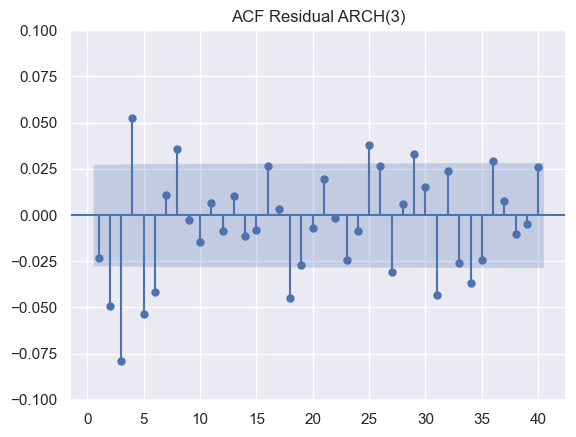

In [30]:
#plot ACF and PACF        
sgt.plot_acf(df.resid_arch_3[1:],zero=False,lags=40)
plt.ylim(-.1,.1)
plt.title("ACF Residual ARCH(3)")
plt.show()


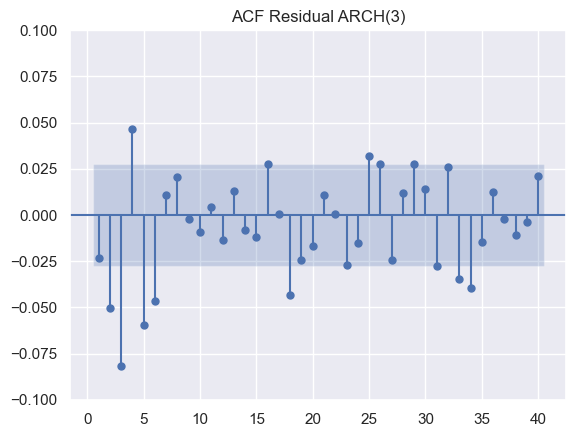

In [31]:
sgt.plot_pacf(df.resid_arch_3[1:],zero=False,lags=40,alpha=.05, method='ols')
plt.ylim(-.1,.1)
plt.title("ACF Residual ARCH(3)")
plt.show()


In [32]:
# Let us automate it till ARCH(14)
dict_model = {}
for i in range(4,15):
    model = arch_model(df.returns[1:], mean='Constant', vol='ARCH',p=i,q=1)
    dict_model[f'ARCH({i})'] = model
    result= model.fit()
    print(f'\t\tARCH({i}) Model Summary ->\n')
    print(result.summary())
    print('\n')

Iteration:      1,   Func. Count:      8,   Neg. LLF: 192823.526714778
Iteration:      2,   Func. Count:     19,   Neg. LLF: 3036099.777755352
Iteration:      3,   Func. Count:     28,   Neg. LLF: 8202.920717274774
Iteration:      4,   Func. Count:     37,   Neg. LLF: 9866.287157819155
Iteration:      5,   Func. Count:     46,   Neg. LLF: 7924.316855105459
Iteration:      6,   Func. Count:     55,   Neg. LLF: 7351.551999622361
Iteration:      7,   Func. Count:     63,   Neg. LLF: 7273.9241027005955
Iteration:      8,   Func. Count:     72,   Neg. LLF: 7583.867907985907
Iteration:      9,   Func. Count:     81,   Neg. LLF: 7186.124982563037
Iteration:     10,   Func. Count:     89,   Neg. LLF: 7183.8513027320505
Iteration:     11,   Func. Count:     96,   Neg. LLF: 7183.85109697941
Iteration:     12,   Func. Count:    103,   Neg. LLF: 7183.851092095075
Iteration:     13,   Func. Count:    109,   Neg. LLF: 7183.851092095152
Optimization terminated successfully    (Exit mode 0)
          

`SUMMARY`                                                                                                                
`Up to ARCH(12) Model we get better and better fit models and all the variance components are significant`                 
`In ARCH(13) and ARCH(14), we get Insingnificant components`                                                              
`Also As we increase complexity -> AIC AND BIC decreases slowly and LLR increases slowly`